In [144]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import rasterio
from scipy.signal import convolve2d

from scipy.ndimage import label
import numpy as np
from rasterio.transform import rowcol

## Defining initial triangulation and target function (Elevation interpolation)

In [145]:
# Load real raster data
bathyfile = "/home/ebr/projects/release-volume-sampler/input/bathy/messina_001/bathy_truncated.tif"

src = rasterio.open(bathyfile)
#data = np.ma.masked_equal(src.read(1), src.nodata)

bathy = src.read(1)
bathy_msk = np.where(src.read_masks(1) == src.nodata, False, True)
profile = src.profile.copy()

# Partition bathy into connected components and select.
labeled, num_features = label(bathy_msk)
label_component = 2

# Get the shape of the data (number of rows and columns)
rows, cols = bathy.shape

# Create a grid of row and column indices
row_indices, col_indices = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")

# Convert pixel indices to geographic coordinates (lon, lat)
lons, lats = rasterio.transform.xy(src.transform, row_indices, col_indices)

# Optionally, convert the lists of latitudes and longitudes to arrays
lons = np.array(lons)
lats = np.array(lats)

In [146]:

# Create triangulation.

# select points
# Create a strided mask (downsample the raster)
num_points_lat, num_points_lon = 40, 60  # Choose your stride factor (e.g., every 5th pixel)
row_indices_triang, col_indices_triang = np.meshgrid(
    np.linspace(0, rows-1, num=num_points_lat, dtype=int), np.linspace(0, cols-1, num=num_points_lon, dtype=int), indexing="ij"
)
# Convert pixel indices to geographic coordinates (lon, lat)
lons_triang, lats_triang = rasterio.transform.xy(src.transform, row_indices_triang, col_indices_triang)

# Optionally, convert the lists of latitudes and longitudes to arrays
lons_triang = np.array(lons_triang)
lats_triang = np.array(lats_triang)
triang_mask = labeled[row_indices_triang, col_indices_triang] == label_component

# Add extra boundry vertices to ensure that the entire region is contained in triangulation.
triang_mask_buff = convolve2d(triang_mask, np.ones((3, 3)), mode='same')> 0.

is_raster_boundary = np.full(triang_mask.shape, False)
is_raster_boundary[0,:] = True
is_raster_boundary[-1,:] = True
is_raster_boundary[:,0] = True
is_raster_boundary[:,-1] = True

triang_mask_boundary = is_raster_boundary & triang_mask | triang_mask_buff & ~triang_mask
triang_mask_interior = triang_mask & ~triang_mask_boundary

interior_points = np.vstack([lons_triang[triang_mask_interior], lats_triang[triang_mask_interior]]).T
boundary_points = np.vstack([lons_triang[triang_mask_boundary], lats_triang[triang_mask_boundary]]).T
triang_points = np.vstack([interior_points, boundary_points])
triang_point_is_boundary = np.hstack([np.zeros(interior_points.shape[0]), np.ones(boundary_points.shape[0])])

# Create Delaunay Triangulation
tri = Delaunay(triang_points)
vertices = tf.Variable(triang_points, dtype=tf.float32)  # TensorFlow variable for optimization
triangles = tri.simplices  # Indices of vertices for each triangle

# Filter out triangles only associated with boundary points
filtered_triangles = []
for simplex in tri.simplices:
    # Check if all points in the triangle are boundary points
    if not all(triang_point_is_boundary[simplex]):
        filtered_triangles.append(simplex)

filtered_triangles = np.array(filtered_triangles)

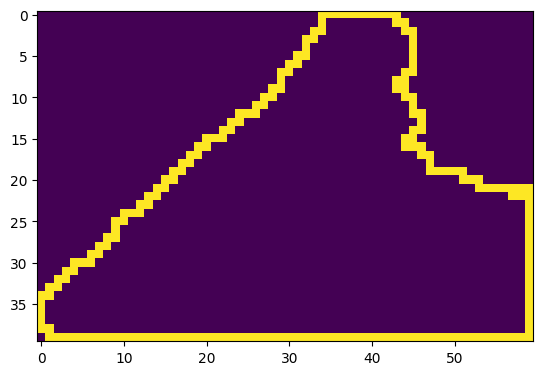

In [147]:
plt.imshow(triang_mask_boundary) 

In [148]:
# Create points for evaluation.
nr_of_rows_eval, nr_of_cols_eval = 400, 300

row_indices_eval, col_indices_eval = np.meshgrid(
    np.linspace(0, rows-1, num=nr_of_rows_eval, dtype=int), np.linspace(0, cols-1, num=nr_of_cols_eval, dtype=int), indexing="ij"
)
# Convert pixel indices to geographic coordinates (lon, lat)
lons_eval, lats_eval = rasterio.transform.xy(src.transform, row_indices_eval, col_indices_eval)

# Optionally, convert the lists of latitudes and longitudes to arrays
lons_eval = np.array(lons_eval)
lats_eval = np.array(lats_eval)
eval_msk = labeled[row_indices_eval, col_indices_eval] == label_component

eval_points = np.vstack([lons_eval[eval_msk], lats_eval[eval_msk]]).T

In [149]:
def target_elevation_function(points):
    lon, lat = points[:, 0], points[:, 1]
    rows, cols = rowcol(src.transform, lon, lat)
    
    # Clamp row and col to ensure they are within the raster bounds
    rows = np.clip(rows, 0, bathy.shape[0] - 1)
    cols = np.clip(cols, 0, bathy.shape[1] - 1)
    
    return tf.cast(bathy[rows, cols], tf.float32)  # Synthetic elevation function

In [150]:
triangles

array([[1310, 1329, 1374],
       [1366, 1361, 1383],
       [1401, 1387, 1383],
       ...,
       [1179, 1120, 1178],
       [1120, 1177, 1178],
       [1120, 1119, 1177]], dtype=int32)

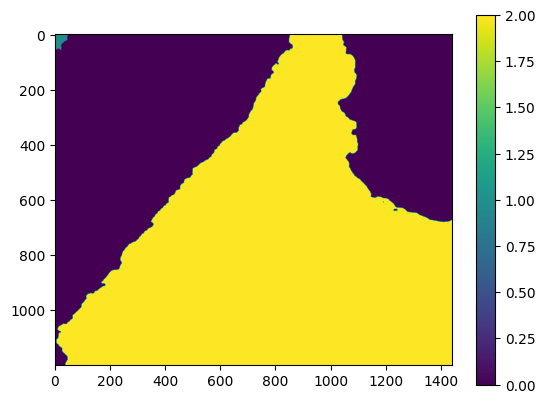

In [151]:
plt.imshow(labeled)
plt.colorbar()

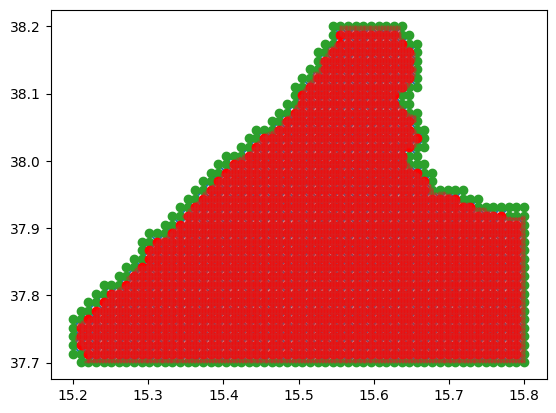

In [152]:
def plot_triangulation():
    plt.triplot(triang_points[:,0], triang_points[:,1], filtered_triangles)
    plt.plot(boundary_points[:,0], boundary_points[:,1], 'o')
    plt.plot(interior_points[:,0], interior_points[:,1], 'o', c='r')
    plt.plot(eval_points[:,0], eval_points[:,1], 'o', markersize=0.2)
    plt.show()

plot_triangulation()

In [153]:
true_elevations = target_elevation_function(eval_points)

## Optimize vertice location.

In [154]:
# Helper function to evaluate elevation within a triangle based on 3D plane through its vertices
def evaluate_elevation(points, vertices, triangles):
    """
    Evaluates the elevation of points based on the plane defined by the containing triangle's vertices.
    """
    elevations = []
    for point in points:
        # Step 1: Find the triangle containing the point
        simplex = tri.find_simplex(point)  # Index of triangle containing point
        if simplex == -1:
            raise ValueError("Point is outside triangulation boundaries.")

        tri_indices = triangles[simplex]
        p1, p2, p3 = tf.gather(vertices, tri_indices)  # Get the triangle's vertices (x, y)

        # Sample elevations at the vertices
        z1, z2, z3 = target_elevation_function(np.array([p1, p2, p3]))

        # Convert triangle vertices to 3D points including elevation: (x, y, z)
        v1 = tf.concat([p1, [z1]], axis=0)
        v2 = tf.concat([p2, [z2]], axis=0)
        v3 = tf.concat([p3, [z3]], axis=0)

        # Step 2: Compute the normal vector of the plane using cross product of (v2-v1) and (v3-v1)
        normal = tf.linalg.cross(v2 - v1, v3 - v1)
        a, b, c = normal
        d = -(a * v1[0] + b * v1[1] + c * v1[2])

        # Calculate z for the point (x, y) in the plane
        elevation = -(a * point[0] + b * point[1] + d) / c
        elevations.append(elevation)

    return tf.stack(elevations)

In [155]:
def evaluate_elevation(points, vertices, triangles):
    """
    Evaluates the elevation of points based on the plane defined by the containing triangle's vertices.
    Vectorized to avoid loops for efficiency.
    """
    
    # Step 1: Find which triangle contains each point
    # Assumption: points are 2D, so we need to add them to the 3D triangulation.
    points = tf.convert_to_tensor(points, dtype=tf.float32)

    # Find the triangle containing each point
    simplexes = tri.find_simplex(points)  # Index of triangle containing each point
    simplex_is_valid = simplexes != -1  # Filter out points outside the triangulation
    simplexes = simplexes[simplex_is_valid]
    valid_points = points[simplex_is_valid]

    vertice_elevations = tf.reshape(target_elevation_function(vertices),[-1,1])
    vertices_3d = tf.concat([vertices, vertice_elevations], axis=1)
    # Step 2: Gather all vertices for the triangles containing the points
    tri_indices = triangles[simplexes]  # Get the triangle indices for valid points
    p1_p2_p3 = tf.gather(vertices_3d, tri_indices)  # Get the triangle's vertices for the valid points
    p1, p2, p3 = p1_p2_p3[:,0,:], p1_p2_p3[:,1,:], p1_p2_p3[:,2,:]

    # Step 5: Compute the normal vector of the plane for each triangle using the cross product
    normal = tf.linalg.cross(p2 - p1, p3 - p1)
    a, b, c = tf.unstack(normal, axis=1)  # Extract coefficients a, b, c of the plane

    # Step 6: Compute the d coefficient of the plane equation (ax + by + cz + d = 0)
    d = -(a * p1[:, 0] + b * p1[:, 1] + c * p1[:, 2])

    # Compute the elevation (z) for each point (x, y)
    elevation_valid = -(a * valid_points[:, 0] + b * valid_points[:, 1] + d) / c

    # Use tf.scatter_nd to create the full elevation tensor
    elevation = tf.scatter_nd(
        indices=tf.where(simplex_is_valid),
        updates=elevation_valid,
        shape=[tf.shape(points)[0]]
    )

    return elevation

In [156]:
def compute_shape_loss(vertices, triangles, triang_point_is_boundary):
    """
    Computes the shape loss based on the aspect ratio for all triangles,
    vectorized for efficiency.
    """
    # Mask triangles with boundary points only
    boundary_mask = tf.reduce_all(tf.gather(triang_point_is_boundary, triangles) == 1, axis=1)
    non_boundary_triangles = tf.boolean_mask(triangles, ~boundary_mask)

    # Gather vertices for each triangle (shape: [num_triangles, 3, 2])
    p1, p2, p3 = tf.gather(vertices, non_boundary_triangles[:, 0]), tf.gather(vertices, non_boundary_triangles[:, 1]), tf.gather(vertices, non_boundary_triangles[:, 2])

    # Compute edge lengths (shape: [num_triangles])
    edge1 = tf.norm(p2 - p1, axis=1)
    edge2 = tf.norm(p3 - p2, axis=1)
    edge3 = tf.norm(p1 - p3, axis=1)

    # Compute perimeter and semi-perimeter
    perimeter = edge1 + edge2 + edge3
    semi_perimeter = perimeter / 2.0

    # Compute area using Heron's formula
    area = tf.sqrt(semi_perimeter * (semi_perimeter - edge1) * (semi_perimeter - edge2) * (semi_perimeter - edge3))

    # Calculate aspect ratio for each triangle
    aspect_ratio = (12 * tf.sqrt(3.0) * area) / (perimeter ** 2)

    # Step 7: Compute shape loss
    shape_loss = tf.reduce_sum(1.0 - aspect_ratio)  # Sum of penalties for low aspect ratio
    
    # Step 8: Add a penalty for large triangle areas (squared area penalty)
    area_loss = tf.reduce_sum(area ** 2)


    return shape_loss, area_loss


In [159]:

# 3. Define a Loss Function

def compute_loss(vertices, triangles, sample_points, true_elevations):
    # Shape term: Penalize triangles with bad aspect ratios 
    shape_loss, area_loss = compute_shape_loss(vertices, triangles, triang_point_is_boundary)
    
    # Elevation accuracy term
    # Evaluate predicted and true elevations at sample points within triangles
    predicted_elevations = evaluate_elevation(sample_points, vertices, triangles)
    elevation_loss = tf.reduce_mean((predicted_elevations - true_elevations) ** 2)  # L2 difference from true elevation
    return elevation_loss, shape_loss, area_loss


Sample points for test case

In [166]:
# 4. Optimization Loop
optimizer = tf.optimizers.Adam(learning_rate=5e-4)
interior_mask =  tf.cast(1- triang_point_is_boundary, dtype=tf.float32)

num_iterations = 1000

shape_weight = 1e-3 # Recall that this is weighted against average depth residuals.
area_weight = 1e5
elevation_weight = 1e-5

for i in range(num_iterations):
    with tf.GradientTape() as tape:
        elevation_loss, shape_loss, area_loss =  compute_loss(vertices, triangles, eval_points, true_elevations)
        loss = shape_weight*shape_loss + area_weight*area_loss + elevation_weight*elevation_loss # Add loss for points outside of domain?
    gradients = tape.gradient(loss, [vertices])
    
    # Apply mask to gradients: zero out gradients for boundary points
    gradients_fixed = gradients[0] * tf.reshape(interior_mask, (-1, 1)) 
    optimizer.apply_gradients([(gradients_fixed, vertices)])
    
    if i % 50 == 0:
        print(f"Iteration {i}: Loss: {loss.numpy()}, Elevation loss {elevation_weight*elevation_loss.numpy()}, Shape loss: {shape_weight*shape_loss.numpy()}, Area loss: {area_weight*area_loss.numpy()}")


Iteration 0: Loss: 1.5497565269470215, Elevation loss 0.1528504490852356, Shape loss: 0.22139382362365723, Area loss: 1.1755123138427734
Iteration 50: Loss: 1.5498085021972656, Elevation loss 0.15284575521945953, Shape loss: 0.22141194343566895, Area loss: 1.1755508184432983
Iteration 100: Loss: 1.5497679710388184, Elevation loss 0.15285712480545044, Shape loss: 0.2213926464319229, Area loss: 1.175518274307251
Iteration 150: Loss: 1.5497676134109497, Elevation loss 0.1528574675321579, Shape loss: 0.2213934063911438, Area loss: 1.1755167245864868
Iteration 200: Loss: 1.5497676134109497, Elevation loss 0.15285718441009521, Shape loss: 0.22139936685562134, Area loss: 1.175511121749878
Iteration 250: Loss: 1.5497677326202393, Elevation loss 0.15285754203796387, Shape loss: 0.22139231860637665, Area loss: 1.1755179166793823
Iteration 300: Loss: 1.5497684478759766, Elevation loss 0.15285731852054596, Shape loss: 0.2213897407054901, Area loss: 1.1755213737487793
Iteration 350: Loss: 1.5497678

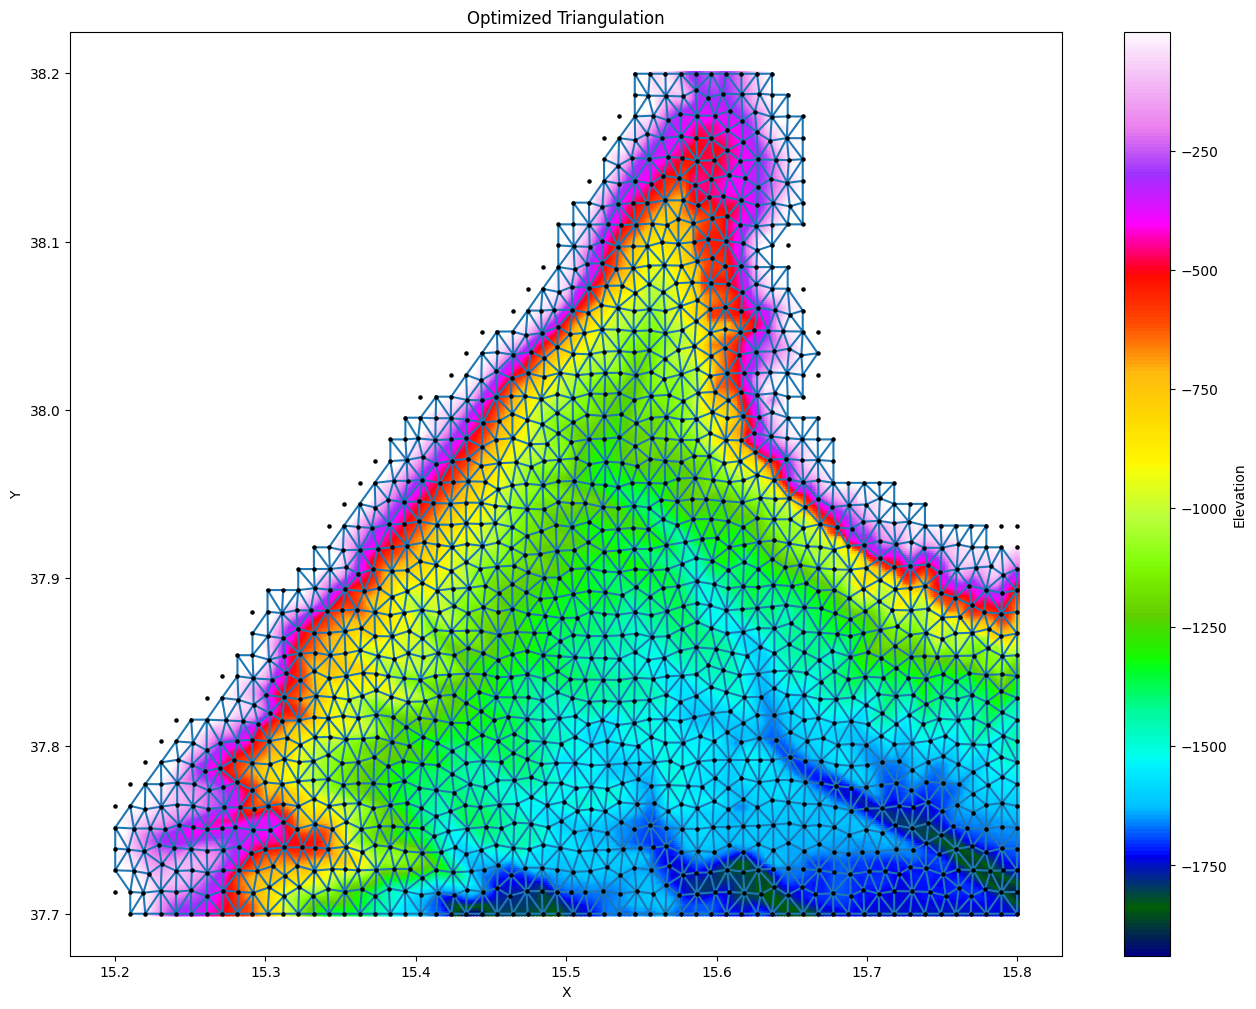

In [167]:
import matplotlib.cm as cm

plt.figure(figsize=(16, 12))

# Evaluation points.
cmap = cm.gist_ncar  # Or any other colormap
elevations = true_elevations.numpy()
norm = plt.Normalize(vmin=min(elevations), vmax=max(elevations))
sc=plt.scatter(eval_points[:,0], eval_points[:,1], c=elevations, cmap=cmap, norm=norm, s=10)
plt.colorbar(sc, label="Elevation")

# Visualization of Final Triangulation (optional)
plt.triplot(vertices[:, 0].numpy(), vertices[:, 1].numpy(), filtered_triangles)
plt.scatter(vertices[:, 0].numpy(), vertices[:, 1].numpy(), c="k", s=5)


plt.title("Optimized Triangulation")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Plot triangulation.

In [164]:
elevation = evaluate_elevation(triang_points, vertices, triangles)

In [165]:
import plotly.graph_objects as go

# 3. Create the 3D interactive plot using Plotly
fig = go.Figure()

# Plot the points
fig.add_trace(go.Scatter3d(
    x=vertices[:, 0], 
    y=vertices[:, 1], 
    z=elevation, 
    mode='markers', 
    marker=dict(size=5, color=elevation, colorscale='Viridis', colorbar=dict(title='Elevation'))
))

# Plot the triangulation (edges of the triangles)
for simplex in tri.simplices:
    simplex_points = tf.stack([vertices[i] for i in simplex])
    x_vals = simplex_points[:, 0]
    y_vals = simplex_points[:, 1]
    z_vals = tf.stack([elevation[i] for i in simplex])
    # Connect the triangle vertices using a surface plot
    fig.add_trace(go.Mesh3d(
        x=x_vals, 
        y=y_vals, 
        z=z_vals, 
        opacity=0.5, 
        color='gray'
    ))

# Update layout for better appearance
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Elevation (Z)',
    ),
    title="Interactive 3D Triangulation of Elevation Data",
    margin=dict(r=10, l=10, b=10, t=40),
    template="plotly"
)

# Show the interactive plot
fig.show()


In [73]:
tf.stack([vertices[i] for i in simplex])

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0.4552358 , 3.0388098 ],
       [0.10676707, 2.6804626 ],
       [0.52740055, 2.6293826 ]], dtype=float32)>